# Работа 2: Поиск ассоциативных правил

## 1. Формулировка задания
1. Доработать программу поиска частых наборов, реализовав поиск ассоциативных правил вида A -> B.
  - Результат должен содержать антецедент, консеквент, поддержку (Support) и достоверность (Confidence).
  - Параметры: порог достоверности (min_confidence), способ упорядочивания (по поддержке или по алфавиту).

2. Провести эксперименты: зафиксировать поддержку (например, 1%), варьировать достоверность от 5% до 55% с шагом 5%.
3. Построить диаграммы быстродействия и количества найденных правил.
4. Подготовить список правил с числом объектов <= 7 и разобрать их содержательный смысл.

---
## 2. Ссылка на репозиторий проекта
Каталог репозиторий: `https://github.com/GeRoNioPLAY/Data_analysis`

In [35]:
import time
from collections import defaultdict
from itertools import combinations

import matplotlib.pyplot as plt
import numpy as np

In [36]:
def load_baskets_csv(filepath):
    transactions = []
    with open(filepath, encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            items = [
                item.strip().strip("\"'") for item in line.split(",") if item.strip()
            ]
            if items:
                transactions.append(frozenset(items))
    return transactions


def get_frequent_1_itemsets(transactions, min_support_count, num_transactions):
    counts = defaultdict(int)
    for transaction in transactions:
        for item in transaction:
            counts[frozenset([item])] += 1

    frequent_1 = {}
    for itemset, count in counts.items():
        if count >= min_support_count:
            frequent_1[itemset] = count / num_transactions
    return frequent_1


def generate_candidates(frequent_prev, k):
    prev_itemsets = list(frequent_prev.keys())
    candidates = set()
    n = len(prev_itemsets)

    for i in range(n):
        for j in range(i + 1, n):
            union_set = prev_itemsets[i] | prev_itemsets[j]
            if len(union_set) == k:
                all_subsets_frequent = True
                for subset in combinations(union_set, k - 1):
                    if frozenset(subset) not in frequent_prev:
                        all_subsets_frequent = False
                        break
                if all_subsets_frequent:
                    candidates.add(union_set)
    return candidates


def apriori(transactions, min_support=0.05, sort_by="support_desc"):
    num_transactions = len(transactions)
    if num_transactions == 0:
        return [], {}

    min_support_count = min_support * num_transactions
    all_frequent_by_length = {}

    l1 = get_frequent_1_itemsets(transactions, min_support_count, num_transactions)
    if not l1:
        return [], {}

    all_frequent_by_length[1] = l1
    current_l = l1
    k = 2

    while current_l:
        ck = generate_candidates(current_l, k)
        if not ck:
            break

        counts = defaultdict(int)
        for transaction in transactions:
            for candidate in ck:
                if candidate.issubset(transaction):
                    counts[candidate] += 1

        lk = {}
        for candidate, count in counts.items():
            if count >= min_support_count:
                lk[candidate] = count / num_transactions

        if lk:
            all_frequent_by_length[k] = lk
            current_l = lk
            k += 1
        else:
            break

    flat_results = []
    for itemsets in all_frequent_by_length.values():
        for itemset, support in itemsets.items():
            flat_results.append((sorted(itemset), support))

    if sort_by == "support_desc":
        flat_results.sort(key=lambda x: (-x[1], x[0]))
    elif sort_by == "lexicographical":
        flat_results.sort(key=lambda x: x[0])
    else:
        raise ValueError(
            "Параметр sort_by должен быть 'support_desc' или 'lexicographical'"
        )

    frequent_dict = {itemset: sup for itemsets in all_frequent_by_length.values() for itemset, sup in itemsets.items()}
    return frequent_dict

In [37]:
def generate_rules(frequent_itemsets, min_confidence=0.7):
    rules = []

    for itemset, itemset_support in frequent_itemsets.items():
        k = len(itemset)
        if k < 2:
            continue

        item_list = list(itemset)
        for r in range(1, k):
            for ant_tuple in combinations(item_list, r):
                antecedent = frozenset(ant_tuple)
                consequent = itemset - antecedent

                ant_support = frequent_itemsets.get(antecedent)
                if not ant_support:
                    continue

                confidence = itemset_support / ant_support

                if confidence >= min_confidence:
                    rules.append({
                        "antecedent": tuple(sorted(antecedent)),
                        "consequent": tuple(sorted(consequent)),
                        "support": itemset_support,
                        "confidence": confidence,
                        "total_len": len(antecedent) + len(consequent)
                    })

    return rules

In [38]:
def format_rule(rule):
    ant = "{" + ", ".join(rule["antecedent"]) + "}"
    con = "{" + ", ".join(rule["consequent"]) + "}"
    return f"{ant} -> {con} | Support: {rule['support']:.4f}, Confidence: {rule['confidence']:.4f}"

## 3. Демонстрация работы программы

In [39]:
dataset_path = "../lab1/baskets.csv"

transactions = load_baskets_csv(dataset_path)
print(f"Загружено транзакций: {len(transactions)}")

frequent_dict = apriori(transactions, min_support=0.01)
rules_desc = generate_rules(frequent_dict, min_confidence=0.3)

print(f"\nВсего найдено правил (Confidence >= 30%): {len(rules_desc)}")
print("\n--- Топ-5 правил (по убыванию поддержки): ---")
for r in rules_desc[:5]:
    print(format_rule(r))

short_rules = [r for r in rules_desc if r["total_len"] <= 7]
print(f"\n--- Список правил с числом объектов <= 7 (всего {len(short_rules)}): ---")
for i, r in enumerate(short_rules[:10], start=1):
    print(f"{i}. {format_rule(r)}")

Загружено транзакций: 7501

Всего найдено правил (Confidence >= 30%): 65

--- Топ-5 правил (по убыванию поддержки): ---
{мед} -> {минеральная вода} | Support: 0.0151, Confidence: 0.3174
{креветки} -> {минеральная вода} | Support: 0.0236, Confidence: 0.3302
{авокадо} -> {минеральная вода} | Support: 0.0116, Confidence: 0.3480
{замороженный смузи} -> {минеральная вода} | Support: 0.0203, Confidence: 0.3200
{лосось} -> {минеральная вода} | Support: 0.0171, Confidence: 0.4013

--- Список правил с числом объектов <= 7 (всего 65): ---
1. {мед} -> {минеральная вода} | Support: 0.0151, Confidence: 0.3174
2. {креветки} -> {минеральная вода} | Support: 0.0236, Confidence: 0.3302
3. {авокадо} -> {минеральная вода} | Support: 0.0116, Confidence: 0.3480
4. {замороженный смузи} -> {минеральная вода} | Support: 0.0203, Confidence: 0.3200
5. {лосось} -> {минеральная вода} | Support: 0.0171, Confidence: 0.4013
6. {низкокалорийный йогурт} -> {минеральная вода} | Support: 0.0240, Confidence: 0.3136
7. {о

## 4. Эксперименты

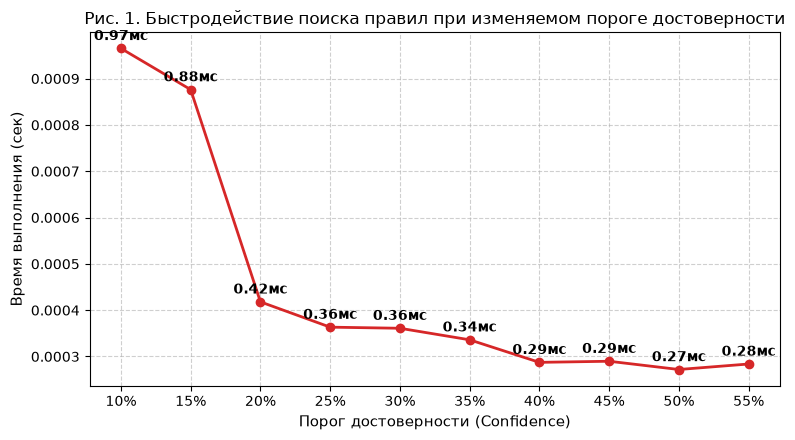

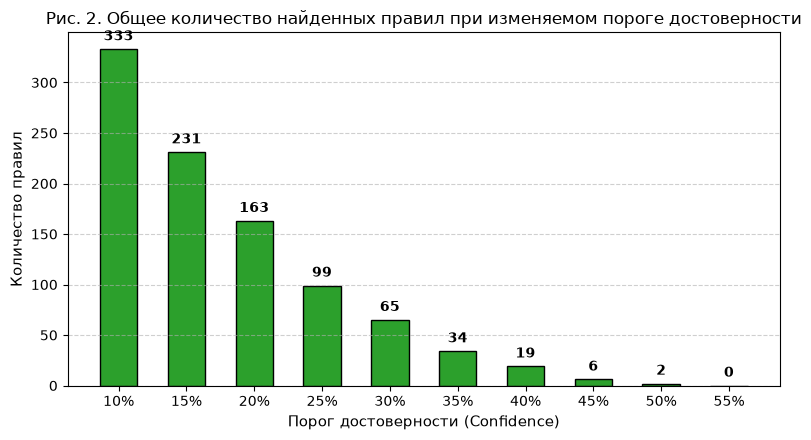

In [40]:
confidence_thresholds = [0.10, 0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.55]
mining_times = []
rules_counts = []

for conf in confidence_thresholds:
    start_time = time.perf_counter()
    rules = generate_rules(frequent_dict, min_confidence=conf)
    elapsed = time.perf_counter() - start_time
    mining_times.append(elapsed)
    rules_counts.append(len(rules))

conf_labels = [f"{int(c * 100)}%" for c in confidence_thresholds]

plt.figure(figsize=(8, 4.5))
plt.plot(confidence_thresholds, mining_times, marker="o", color="#d62728", linewidth=2)
plt.title("Рис. 1. Быстродействие поиска правил при изменяемом пороге достоверности", fontsize=12)
plt.xlabel("Порог достоверности (Confidence)", fontsize=11)
plt.ylabel("Время выполнения (сек)", fontsize=11)
plt.xticks(confidence_thresholds, conf_labels)
plt.grid(True, linestyle="--", alpha=0.6)
for x, y in zip(confidence_thresholds, mining_times):
    plt.annotate(f"{y*1000:.2f}мс", (x, y), textcoords="offset points", xytext=(0, 6), ha="center", fontweight="bold")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 4.5))
bars = plt.bar(conf_labels, rules_counts, color="#2ca02c", edgecolor="black", width=0.55)
for bar in bars:
    h = bar.get_height()
    plt.annotate(f"{int(h)}", xy=(bar.get_x() + bar.get_width() / 2, h), xytext=(0, 4),
                 textcoords="offset points", ha="center", va="bottom", fontweight="bold")
plt.title("Рис. 2. Общее количество найденных правил при изменяемом пороге достоверности", fontsize=12)
plt.xlabel("Порог достоверности (Confidence)", fontsize=11)
plt.ylabel("Количество правил", fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.6)
plt.tight_layout()
plt.show()

## 5. Выводы
1. Разработанная программа успешно решает задачу извлечения ассоциативных правил вида $A \to B$ с вычислением метрик Support и Confidence и возможностью сортировки.
2. Экспериментально подтверждено, что генерация правил из готовых частых наборов выполняется за доли миллисекунды и не требует повторного обхода базы транзакций.
3. Фильтрация по длине ($\le 7$) и порогу достоверности 30%–40% позволила выделить практически значимые правила, пригодные для оптимизации выкладки товаров и настройки рекомендательных систем.